# Question-Question Opinion Network

This notebook constructs and analyzes a network in which the **60 survey statements are nodes**. Two questions are connected when respondents answer them in sufficiently similar or opposing ways.

The analysis is designed to answer four questions:

1. Which beliefs tend to be held together?
2. Do the four predefined domains—Technology, Education, Society/Ethics, and Environment—form distinct empirical groups?
3. Which questions connect otherwise different opinion themes?
4. Which relationships remain visible after accounting for respondents who generally agree with most statements?

This is an association network, not a causal or social-interaction network. An edge means that two response patterns are statistically associated; it does not mean that one belief causes another.

## Assumptions and analytical decisions

The following assumptions are fixed before inspecting the final graph:

- **Ordinal encoding:** `Strongly Disagree=1`, `Disagree=2`, `Neutral=3`, `Agree=4`, and `Strongly Agree=5`. 
- **Completely empty submissions:** Respondents who answered none of the 60 questions are removed. The dataset contains five such submissions.
- **Remaining missing values:** Blank responses and `No Comments` remain `NaN`. They are not interpreted as Neutral and are not otherwise imputed.
- **Analysis sample:** All non-empty submissions are retained, leaving 91 respondents. A partially completed response contributes only to question pairs for which both answers are observed.
- **Pairwise availability:** Spearman correlations use pairwise-complete observations. A question pair must have at least **60 respondents who answered both questions**.
- **Association measure:** Spearman correlation is used because Likert responses are ordinal. Positive correlation means that respondents tend to move in the same direction on both questions; negative correlation means that they tend to move in opposite directions.
- **Primary edge rule:** An edge is retained when `abs(Spearman rho) >= 0.30`. Thresholds 0.25 and 0.35 are also evaluated as sensitivity checks.
- **Signed network:** Positive and negative edges are preserved. Community detection uses positive edges only because standard Louvain modularity is not designed for signed weights.
- **Community method:** Louvain community detection uses a fixed random seed of 42.
- **Question domains:** Prefixes `T`, `E`, `S`, and `V` are interpreted as Technology, Education, Society/Ethics, and Environment respectively.
- **Privacy:** Respondent IDs are used only to identify rows during cleaning. They are not exported to graph outputs.
- **Statistical interpretation:** The threshold is a substantive network-filtering rule, not a hypothesis-test cutoff. With 1,770 possible pairs, isolated p-values would require multiple-testing correction. The sensitivity analysis is therefore more important than whether an individual edge has an unadjusted p-value below 0.05.

### Justification for the missing-data decision

Five submissions contain no survey answers and therefore provide no opinion information; these rows are removed. The other 91 submissions are retained, but every blank or `No Comments` entry remains missing rather than being converted to Neutral.

For each pair of questions, Spearman correlation is calculated only from respondents who answered both. Requiring at least 60 shared responses prevents a question-network edge from being based on a small subset. This approach avoids inventing midpoint opinions, preserves observed variation, and prevents shared missingness from directly creating correlations. The trade-off is that different question pairs may use slightly different respondents, so each edge stores and exports its paired sample size.

## 1. Imports and configuration


In [2]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd

RANDOM_SEED = 42
MIN_PAIRWISE_RESPONSES = 60
PRIMARY_THRESHOLD = 0.30
SENSITIVITY_THRESHOLDS = (0.25, 0.30, 0.35)

DATA_PATH = Path("Survey_Results_UC.csv")
OUTPUT_DIR = Path(os.environ.get("DPCN_OUTPUT_DIR", "outputs/question_question_network"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ["Technology", "Education", "Society/Ethics", "Environment"]
DOMAIN_COLORS = {
    "Technology": "#4C78A8",
    "Education": "#F58518",
    "Society/Ethics": "#54A24B",
    "Environment": "#B279A2",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
})

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Survey_Results_UC.csv was not found. Run this notebook from the repository root."
    )


## 2. Load and validate the survey

The first column is treated as the response identifier. All remaining columns must follow the `T01. Question text` style and must contain one of the five Likert responses, `No Comments`, or a blank value. The validation below deliberately stops instead of silently converting unexpected text.

In [3]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
response_id_col = raw.columns[0]
question_columns = list(raw.columns[1:])

if len(question_columns) != 60:
    raise ValueError(f"Expected 60 question columns, found {len(question_columns)}.")

expected_prefix_counts = {prefix: 15 for prefix in "TESV"}
observed_prefix_counts = {
    prefix: sum(column.startswith(prefix) for column in question_columns)
    for prefix in expected_prefix_counts
}
if observed_prefix_counts != expected_prefix_counts:
    raise ValueError(
        f"Unexpected question-domain structure: {observed_prefix_counts}"
    )

allowed_text = {
    "Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree",
    "No Comments"
}
observed_text = set(raw[question_columns].stack().dropna().astype(str).unique())
unexpected_text = sorted(observed_text - allowed_text)
if unexpected_text:
    raise ValueError(f"Unexpected response labels: {unexpected_text}")

print(f"Raw respondents: {len(raw)}")
print(f"Question columns: {len(question_columns)}")
print(f"Duplicate response IDs: {raw[response_id_col].duplicated().sum()}")
print(f"Domain counts: {observed_prefix_counts}")
display(raw.iloc[:5, :7])

Raw respondents: 96
Question columns: 60
Duplicate response IDs: 0
Domain counts: {'T': 15, 'E': 15, 'S': 15, 'V': 15}


,id. Response ID,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.,T05. Artificial Intelligence will significantly accelerate scientific discovery.,T06. Most repetitive jobs will eventually be replaced by intelligent automation.
0,11,Agree,Agree,Neutral,Strongly Agree,Strongly Agree,Agree
1,12,Agree,Agree,Strongly Agree,Agree,Neutral,Agree
2,13,Agree,Strongly Agree,Neutral,Disagree,Strongly Agree,Agree
3,14,Neutral,Agree,Neutral,Agree,Agree,Agree
4,16,Neutral,Agree,Strongly Agree,Strongly Agree,Strongly Disagree,Strongly Agree


## 3. Encode responses, remove empty submissions, and preserve missing values

The five Likert categories are encoded from 1 to 5. Blank and `No Comments` cells become `NaN`. Rows with zero observed answers are removed; all other respondents remain available for pairwise-complete correlation.

The notebook prints the response-completeness distribution and the amount of remaining missingness so this choice is transparent.

In [4]:
LIKERT_MAPPING = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5,
}

# The five expected Likert labels are mapped to 1-5. Blank cells and
# "No Comments" map to NaN and remain missing throughout the analysis.
numeric_observed = raw[question_columns].apply(
    lambda column: column.map(LIKERT_MAPPING)
)

valid_response_counts = numeric_observed.notna().sum(axis=1)
completely_empty_mask = valid_response_counts == 0
analysis_mask = ~completely_empty_mask
numeric_eligible = numeric_observed.loc[analysis_mask].copy()

quality_summary = pd.Series({
    "Raw respondents": len(raw),
    "Completely empty submissions removed": int(completely_empty_mask.sum()),
    "Analysis respondents": int(analysis_mask.sum()),
    "Completely answered": int((valid_response_counts == 60).sum()),
    "Blank cells in raw data": int(raw[question_columns].isna().sum().sum()),
    "No Comments cells in raw data": int((raw[question_columns] == "No Comments").sum().sum()),
    "Missing cells retained after dropping empty rows": int(numeric_eligible.isna().sum().sum()),
}, name="Value")

print("Data-quality summary")
display(quality_summary.to_frame())

print("Distribution of observed answers")
display(valid_response_counts.value_counts().sort_index().rename("Respondents").to_frame())

excluded_summary = pd.DataFrame({
    "Response ID": raw.loc[completely_empty_mask, response_id_col],
    "Questions answered": valid_response_counts.loc[completely_empty_mask],
}).sort_values("Response ID")
print("Completely empty submissions removed from the analysis")
display(excluded_summary)

assert len(numeric_eligible) == 91
assert int(numeric_eligible.isna().sum().sum()) == 242
assert numeric_eligible.min().min() >= 1
assert numeric_eligible.max().max() <= 5

Data-quality summary


,Value
Raw respondents,96
Completely empty submissions removed,5
Analysis respondents,91
Completely answered,68
Blank cells in raw data,505
No Comments cells in raw data,37
Missing cells retained after dropping empty rows,242


Distribution of observed answers


,Respondents
0,5
15,4
45,1
50,1
56,3
57,3
58,5
59,6
60,68


Completely empty submissions removed from the analysis


,Response ID,Questions answered
26,44,0
40,60,0
48,68,0
52,73,0
55,78,0


## 4. Create readable question metadata

Graph computations use short question codes such as `T01` and `E12`. The complete wording and original survey domain are retained in a metadata table so that every numerical result can be interpreted correctly.

In [5]:
PREFIX_TO_DOMAIN = {
    "T": "Technology",
    "E": "Education",
    "S": "Society/Ethics",
    "V": "Environment",
}

question_metadata = []
for original_column in question_columns:
    code_part, question_text = original_column.split(".", 1)
    question_code = code_part.strip()
    question_metadata.append({
        "code": question_code,
        "domain": PREFIX_TO_DOMAIN[question_code[0]],
        "question": question_text.strip(),
        "original_column": original_column,
    })

question_metadata = pd.DataFrame(question_metadata).set_index("code")
question_codes = question_metadata.index.tolist()
original_to_code = dict(zip(question_columns, question_codes))
numeric_eligible = numeric_eligible.rename(columns=original_to_code)

display(question_metadata[["domain", "question"]])

,domain,question
code,,
T01,Technology,Artificial Intelligence will improve society m...
T02,Technology,Generative AI tools should be allowed as learn...
T03,Technology,Students should disclose the use of AI in assi...
T04,Technology,Every engineering student should receive forma...
T05,Technology,Artificial Intelligence will significantly acc...
T06,Technology,Most repetitive jobs will eventually be replac...
T07,Technology,Robots should replace humans in hazardous occu...
T08,Technology,AI-assisted diagnosis should become routine in...
T09,Technology,Autonomous vehicles will ultimately make trans...


## 5. Describe individual questions before constructing a network

Correlation and consensus are different. A question can have near-unanimous agreement yet few network connections because there is little variation. This cell records each question's observed sample size, missing count, central tendency, dispersion, and proportion agreeing. All summaries ignore `NaN` values rather than treating them as Neutral.

In [6]:
question_summary = pd.DataFrame(index=question_codes)
question_summary["domain"] = question_metadata["domain"]
question_summary["question"] = question_metadata["question"]
question_summary["valid_n"] = numeric_eligible.notna().sum()
question_summary["missing_n"] = numeric_eligible.isna().sum()
question_summary["mean"] = numeric_eligible.mean()
question_summary["median"] = numeric_eligible.median()
question_summary["std_dev"] = numeric_eligible.std()
question_summary["agree_share"] = (
    (numeric_eligible >= 4).sum() / numeric_eligible.notna().sum()
)

print("Questions with the highest average agreement")
display(question_summary.sort_values("mean", ascending=False).head(10))

print("Questions with the greatest response dispersion")
display(question_summary.sort_values("std_dev", ascending=False).head(10))

Questions with the highest average agreement


,domain,question,valid_n,missing_n,mean,median,std_dev,agree_share
E15,Education,Continuous learning and skill development are ...,87,4,4.712644,5.0,0.503662,0.977011
V13,Environment,Companies should be held accountable for the e...,85,6,4.670588,5.0,0.564595,0.976471
S05,Society/Ethics,Individuals should have greater control over h...,87,4,4.632184,5.0,0.592883,0.942529
E11,Education,University curricula should be updated more fr...,87,4,4.620690,5.0,0.633216,0.942529
V09,Environment,Products should be designed to encourage reuse...,85,6,4.600000,5.0,0.710466,0.941176
V14,Environment,International cooperation is necessary to effe...,85,6,4.552941,5.0,0.645606,0.941176
S11,Society/Ethics,People should be free to express differing opi...,87,4,4.551724,5.0,0.605376,0.965517
E10,Education,Universities should prioritize innovation and ...,87,4,4.528736,5.0,0.696154,0.942529
E14,Education,Strong collaborations between universities and...,87,4,4.528736,5.0,0.696154,0.931034
V01,Environment,Climate change requires immediate global action.,85,6,4.517647,5.0,0.628902,0.929412


Questions with the greatest response dispersion


,domain,question,valid_n,missing_n,mean,median,std_dev,agree_share
E04,Education,High-quality online learning can effectively c...,87,4,3.436782,4.0,1.168393,0.540230
E03,Education,Class attendance should be compulsory for all ...,87,4,2.057471,2.0,1.124322,0.126437
E02,Education,Traditional written examinations accurately me...,87,4,2.839080,3.0,1.119318,0.321839
T08,Technology,AI-assisted diagnosis should become routine in...,90,1,3.077778,3.0,1.093677,0.377778
S02,Society/Ethics,Universities should encourage students to part...,87,4,3.839080,4.0,1.055149,0.724138
E09,Education,Collaborative learning is generally more effec...,86,5,3.790698,4.0,1.041676,0.616279
T07,Technology,Robots should replace humans in hazardous occu...,91,0,4.208791,5.0,1.038337,0.824176
E12,Education,Artificial intelligence should be integrated i...,87,4,3.931034,4.0,1.031967,0.735632
S08,Society/Ethics,Diverse teams generally make better decisions ...,86,5,3.918605,4.0,1.008378,0.662791
T12,Technology,Governments should introduce stricter regulati...,90,1,4.022222,4.0,1.005354,0.755556


### Likert response distributions

The stacked Likert chart provides context for the later network. Percentages use observed answers as the denominator for each question. Missing responses are not displayed as Neutral and are reported separately in `question_summary`.

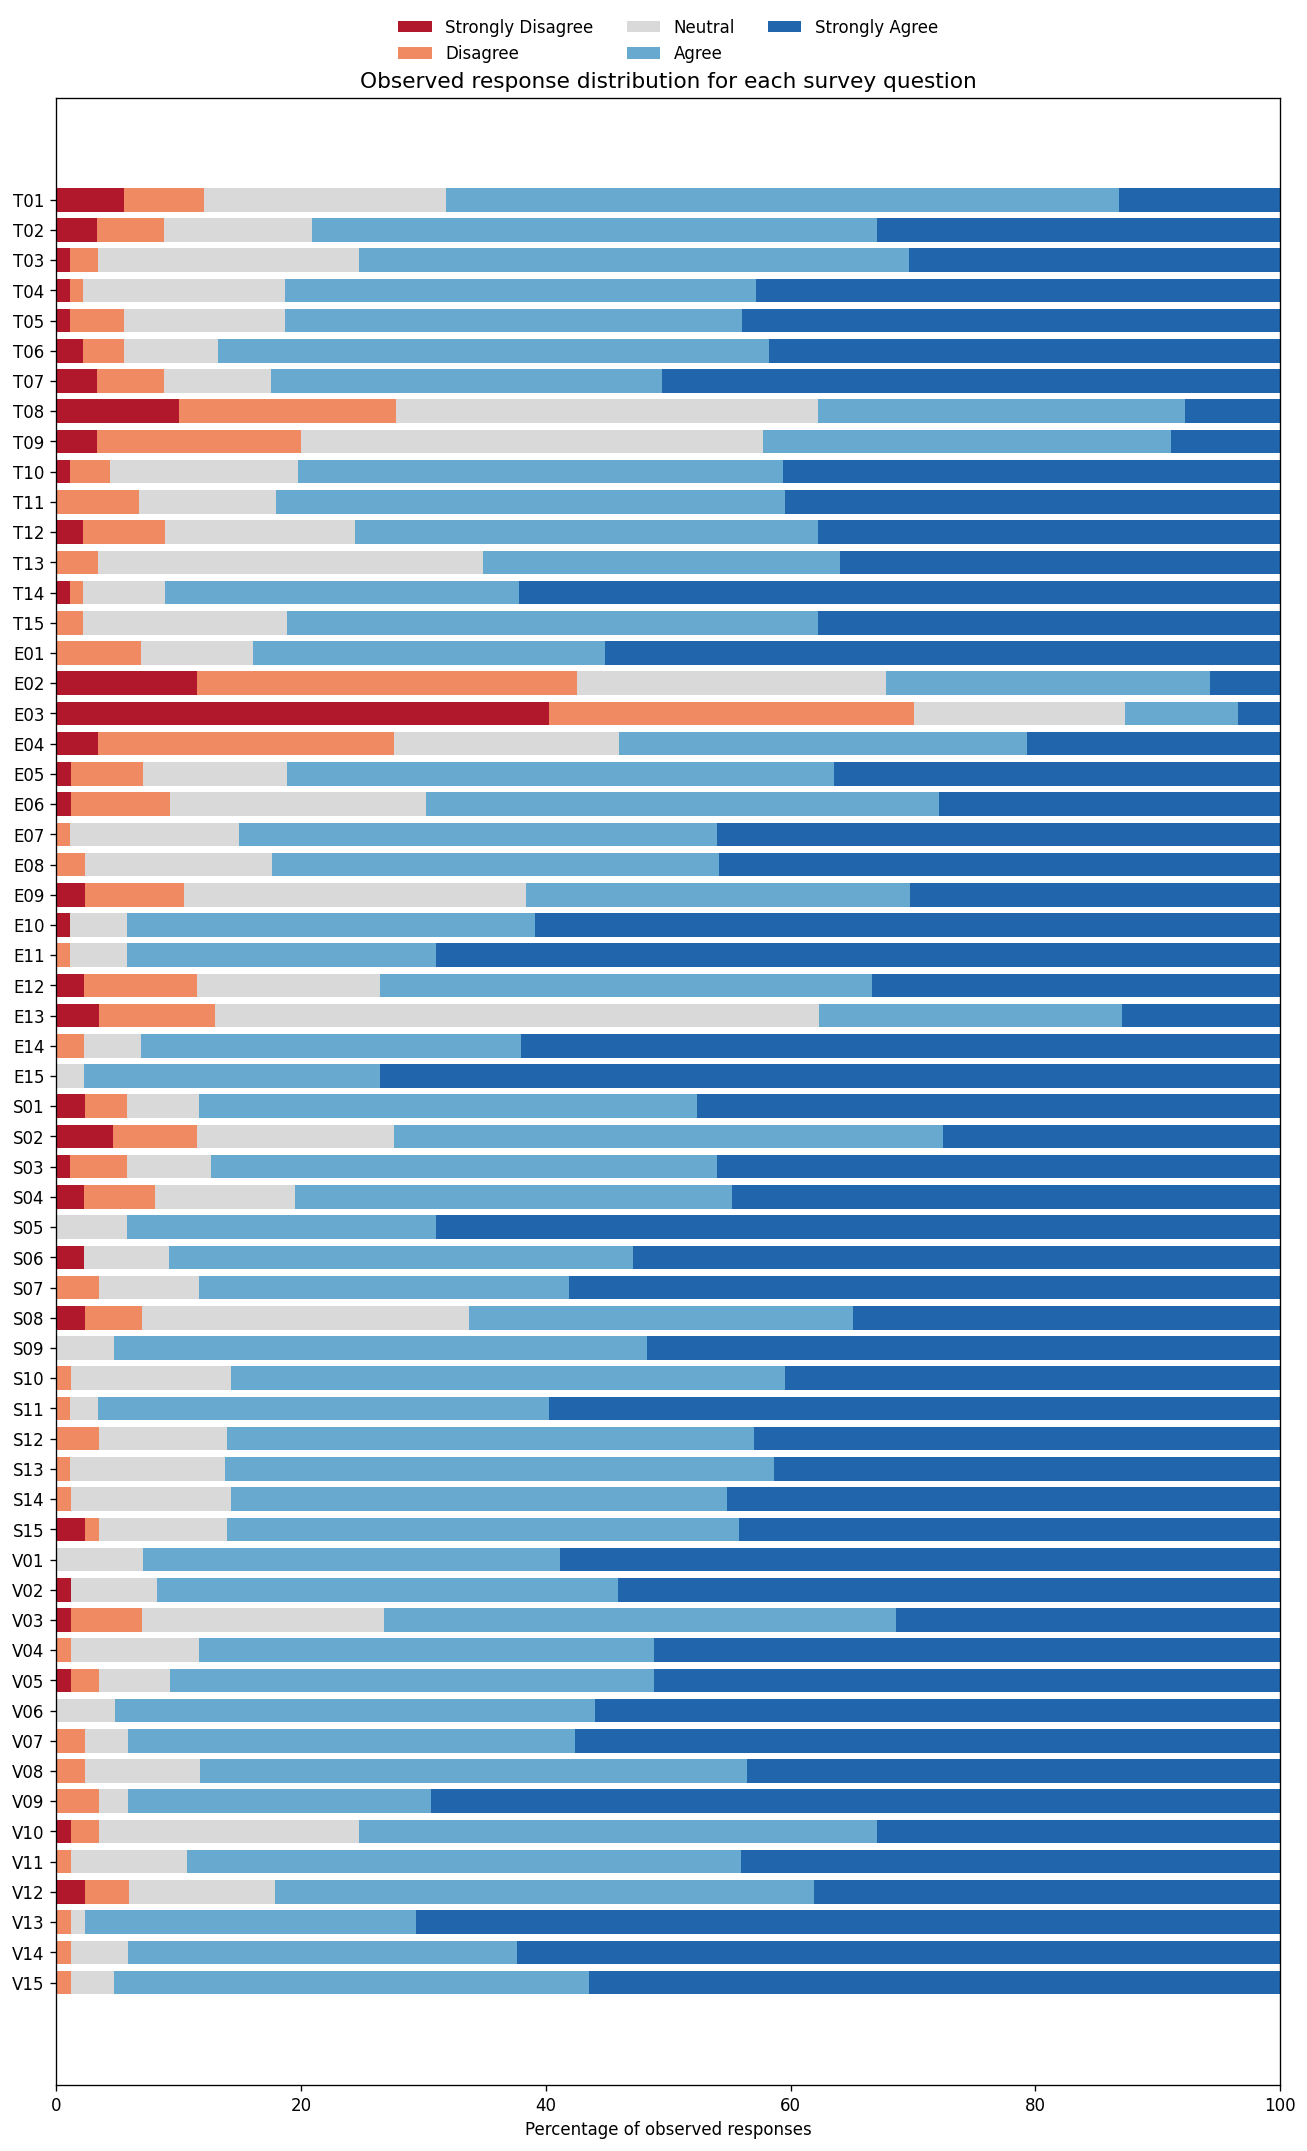

In [7]:
response_order = [
    "Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"
]
response_values = [1, 2, 3, 4, 5]
response_colors = ["#B2182B", "#EF8A62", "#D9D9D9", "#67A9CF", "#2166AC"]

distribution = pd.DataFrame(index=question_codes, columns=response_order, dtype=float)
for question_code in question_codes:
    counts = numeric_eligible[question_code].value_counts().reindex(response_values, fill_value=0)
    observed_n = counts.sum()
    distribution.loc[question_code] = counts.to_numpy() / observed_n * 100

fig, ax = plt.subplots(figsize=(11, 18))
left = np.zeros(len(distribution))
y = np.arange(len(distribution))
for response, color in zip(response_order, response_colors):
    values = distribution[response].to_numpy(dtype=float)
    ax.barh(y, values, left=left, color=color, label=response, height=0.78)
    left += values

for boundary in [14.5, 29.5, 44.5]:
    ax.axhline(boundary, color="white", linewidth=2.2)
ax.set_yticks(y, question_codes)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of observed responses")
ax.set_title("Observed response distribution for each survey question")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.01), frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "likert_distributions.png", bbox_inches="tight")
plt.show()

## 6. Calculate pairwise-complete Spearman correlations

Each question is represented by its observed responses across the 91 non-empty submissions. `pandas.corr(method="spearman")` ranks the values and calculates each correlation using only respondents who answered both questions. `min_periods=60` prevents an association from being estimated from too little shared information.

A separate matrix records the exact number of shared respondents for every question pair. This sample size is also stored on each network edge.

In [8]:
correlation_matrix = numeric_eligible.corr(
    method="spearman",
    min_periods=MIN_PAIRWISE_RESPONSES,
)

observed = numeric_eligible.notna().astype(int)
pairwise_counts = observed.T @ observed

upper_triangle = correlation_matrix.to_numpy()[np.triu_indices(len(question_codes), 1)]
finite_correlations = upper_triangle[np.isfinite(upper_triangle)]
upper_pairwise_counts = pairwise_counts.to_numpy()[np.triu_indices(len(question_codes), 1)]

print(f"Question pairs with valid correlations: {len(finite_correlations):,}")
print(
    "Pairwise sample-size range: "
    f"{int(upper_pairwise_counts.min())} to {int(upper_pairwise_counts.max())}"
)
print(f"Minimum correlation: {finite_correlations.min():.3f}")
print(f"Median absolute correlation: {np.median(np.abs(finite_correlations)):.3f}")
print(f"Maximum correlation: {finite_correlations.max():.3f}")

Question pairs with valid correlations: 1,770
Pairwise sample-size range: 81 to 91
Minimum correlation: -0.405
Median absolute correlation: 0.164
Maximum correlation: 0.652


## 7. Threshold sensitivity and primary network construction

A correlation matrix is complete and difficult to interpret as a network. The function below retains only associations meeting both the minimum sample-size rule and a selected absolute-correlation threshold.

Every retained edge keeps:

- the signed Spearman correlation,
- its absolute value for edge width and weighted strength,
- whether the relationship is positive or negative, and
- the number of respondents used for that pair.

The sensitivity table shows how much the graph changes at thresholds 0.25, 0.30, and 0.35. Conclusions should not depend entirely on one threshold.

In [9]:
def build_question_network(threshold):
    graph = nx.Graph(threshold=threshold)

    for question_code, row in question_metadata.iterrows():
        graph.add_node(
            question_code,
            domain=row["domain"],
            question=row["question"],
        )

    for left_index, left_code in enumerate(question_codes):
        for right_index in range(left_index + 1, len(question_codes)):
            right_code = question_codes[right_index]
            rho = correlation_matrix.loc[left_code, right_code]
            paired_n = int(pairwise_counts.loc[left_code, right_code])

            if (
                np.isfinite(rho)
                and paired_n >= MIN_PAIRWISE_RESPONSES
                and abs(rho) >= threshold
            ):
                graph.add_edge(
                    left_code,
                    right_code,
                    correlation=float(rho),
                    weight=float(abs(rho)),
                    sign="positive" if rho > 0 else "negative",
                    paired_n=paired_n,
                    distance=float(1 / abs(rho)),
                )
    return graph


sensitivity_rows = []
for threshold in SENSITIVITY_THRESHOLDS:
    graph_at_threshold = build_question_network(threshold)
    components = list(nx.connected_components(graph_at_threshold))
    sensitivity_rows.append({
        "threshold": threshold,
        "nodes": graph_at_threshold.number_of_nodes(),
        "edges": graph_at_threshold.number_of_edges(),
        "positive_edges": sum(
            data["correlation"] > 0
            for _, _, data in graph_at_threshold.edges(data=True)
        ),
        "negative_edges": sum(
            data["correlation"] < 0
            for _, _, data in graph_at_threshold.edges(data=True)
        ),
        "isolates": nx.number_of_isolates(graph_at_threshold),
        "components": len(components),
        "largest_component": max(map(len, components)),
        "density": nx.density(graph_at_threshold),
    })

threshold_sensitivity = pd.DataFrame(sensitivity_rows).set_index("threshold")
display(threshold_sensitivity.round(3))

G = build_question_network(PRIMARY_THRESHOLD)
print(
    f"Primary network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
    f"{nx.number_connected_components(G)} components, "
    f"and {nx.number_of_isolates(G)} isolates."
)

,nodes,edges,positive_edges,negative_edges,isolates,components,largest_component,density
threshold,,,,,,,,
0.25,60,494,482,12,0,1,60,0.279
0.30,60,328,322,6,3,4,57,0.185
0.35,60,189,188,1,12,13,48,0.107


Primary network: 60 nodes, 328 edges, 4 components, and 3 isolates.


## 8. Positive-edge communities and network metrics

The signed graph is retained for visualization and centrality. Community detection is performed on the positive-edge subgraph because ordinary Louvain modularity cannot correctly optimize positive and negative weights simultaneously.

- **Degree:** number of retained associations.
- **Strength:** sum of absolute correlations attached to a question.
- **Betweenness:** how frequently a question lies on weighted shortest paths, where stronger correlations are treated as shorter distances.
- **Participation coefficient:** whether a question connects mostly within one survey domain or spreads its connections across several domains. Values closer to one indicate broader cross-domain participation.

Centrality describes position in this constructed association network. It does not establish that a belief is causally important.

In [10]:
G_positive = nx.Graph()
G_positive.add_nodes_from(G.nodes(data=True))
G_positive.add_edges_from(
    (left, right, data)
    for left, right, data in G.edges(data=True)
    if data["correlation"] > 0
)

positive_active_nodes = [node for node, degree in G_positive.degree() if degree > 0]
positive_active_graph = G_positive.subgraph(positive_active_nodes).copy()

if positive_active_graph.number_of_edges() > 0:
    communities = nx.community.louvain_communities(
        positive_active_graph,
        weight="weight",
        resolution=1,
        seed=RANDOM_SEED,
    )
    community_modularity = nx.community.modularity(
        positive_active_graph,
        communities,
        weight="weight",
    )
else:
    communities = []
    community_modularity = np.nan

community_lookup = {node: -1 for node in G.nodes}
for community_number, members in enumerate(communities, start=1):
    for node in members:
        community_lookup[node] = community_number
nx.set_node_attributes(G, community_lookup, "community")

degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G, weight="distance", normalized=True)

positive_strength = {
    node: sum(
        data["weight"]
        for _, _, data in G.edges(node, data=True)
        if data["correlation"] > 0
    )
    for node in G.nodes
}
negative_strength = {
    node: sum(
        data["weight"]
        for _, _, data in G.edges(node, data=True)
        if data["correlation"] < 0
    )
    for node in G.nodes
}

def participation_coefficient(graph, node):
    incident_edges = list(graph.edges(node, data=True))
    total_strength = sum(data["weight"] for _, _, data in incident_edges)
    if total_strength == 0:
        return np.nan

    strength_by_domain = {domain: 0.0 for domain in DOMAIN_ORDER}
    for left, right, data in incident_edges:
        neighbour = right if left == node else left
        neighbour_domain = graph.nodes[neighbour]["domain"]
        strength_by_domain[neighbour_domain] += data["weight"]

    return 1 - sum(
        (domain_strength / total_strength) ** 2
        for domain_strength in strength_by_domain.values()
    )

question_metrics = question_summary.copy()
question_metrics["community"] = pd.Series(community_lookup)
question_metrics["degree"] = pd.Series(degree)
question_metrics["strength"] = pd.Series(strength)
question_metrics["positive_strength"] = pd.Series(positive_strength)
question_metrics["negative_strength"] = pd.Series(negative_strength)
question_metrics["betweenness"] = pd.Series(betweenness)
question_metrics["participation"] = pd.Series({
    node: participation_coefficient(G, node) for node in G.nodes
})

print(f"Positive-edge Louvain communities: {len(communities)}")
print(f"Positive-edge modularity: {community_modularity:.3f}")
print("Community sizes (community -1 means no positive edge at the primary threshold)")
display(question_metrics["community"].value_counts().sort_index().rename("Questions").to_frame())

print("Most strongly connected questions")
display(
    question_metrics.sort_values("strength", ascending=False)[
        ["domain", "question", "community", "degree", "strength", "betweenness", "participation"]
    ].head(12)
)

print("Highest-betweenness bridge questions")
display(
    question_metrics.sort_values("betweenness", ascending=False)[
        ["domain", "question", "community", "degree", "strength", "betweenness", "participation"]
    ].head(12)
)

Positive-edge Louvain communities: 4
Positive-edge modularity: 0.241
Community sizes (community -1 means no positive edge at the primary threshold)


,Questions
community,
-1,7
1,5
2,17
3,13
4,18


Most strongly connected questions


,domain,question,community,degree,strength,betweenness,participation
S09,Society/Ethics,Universities should promote an inclusive envir...,3,28,11.109035,0.091175,0.611607
S14,Society/Ethics,Leaders should prioritize ethical decision-mak...,3,26,9.981788,0.068381,0.648129
V07,Environment,Protecting biodiversity is essential for long-...,4,23,9.707335,0.057276,0.593451
V15,Environment,Current generations have a responsibility to p...,4,25,9.330235,0.039743,0.658421
V08,Environment,Universities should adopt environmentally sust...,4,22,9.003042,0.016365,0.544068
V10,Environment,Consumers should consider environmental impact...,4,22,8.917219,0.019287,0.576871
V12,Environment,Environmental sustainability should be integra...,4,21,8.474782,0.010520,0.503142
V14,Environment,International cooperation is necessary to effe...,4,22,8.340604,0.033314,0.619236
V04,Environment,Public transportation and non-motorized transp...,4,22,8.020762,0.002338,0.495754
S06,Society/Ethics,Combating online misinformation requires share...,4,20,7.469459,0.011689,0.556437


Highest-betweenness bridge questions


,domain,question,community,degree,strength,betweenness,participation
S09,Society/Ethics,Universities should promote an inclusive envir...,3,28,11.109035,0.091175,0.611607
E10,Education,Universities should prioritize innovation and ...,2,19,6.892876,0.091175,0.642602
S14,Society/Ethics,Leaders should prioritize ethical decision-mak...,3,26,9.981788,0.068381,0.648129
E12,Education,Artificial intelligence should be integrated i...,2,13,4.723091,0.068381,0.683219
V07,Environment,Protecting biodiversity is essential for long-...,4,23,9.707335,0.057276,0.593451
E11,Education,University curricula should be updated more fr...,2,21,7.398279,0.050263,0.671728
V09,Environment,Products should be designed to encourage reuse...,4,19,7.213693,0.048510,0.613137
S13,Society/Ethics,Critical evaluation of online information shou...,3,18,6.882947,0.045003,0.661507
E07,Education,Publishing research before graduation should b...,2,15,5.830758,0.043250,0.655653
S11,Society/Ethics,People should be free to express differing opi...,2,20,7.379002,0.042081,0.688896


### Strongest positive and negative relationships

A positive edge indicates beliefs that tend to rise or fall together. A negative edge indicates a contrast: respondents who endorse one statement tend to give lower responses to the other. Negative correlations are reported even when they are rare because they may reveal genuine tensions in the class's opinions.

In [11]:
edge_rows = []
for left, right, data in G.edges(data=True):
    edge_rows.append({
        "question_1": left,
        "question_2": right,
        "domain_1": G.nodes[left]["domain"],
        "domain_2": G.nodes[right]["domain"],
        "correlation": data["correlation"],
        "absolute_correlation": data["weight"],
        "sign": data["sign"],
        "paired_n": data["paired_n"],
    })

edge_table = pd.DataFrame(edge_rows).sort_values(
    "absolute_correlation", ascending=False
)

print("Strongest positive edges")
display(edge_table[edge_table["sign"] == "positive"].head(15))

print("Strongest negative edges")
display(
    edge_table[edge_table["sign"] == "negative"]
    .sort_values("correlation")
    .head(15)
)

Strongest positive edges


,question_1,question_2,domain_1,domain_2,correlation,absolute_correlation,sign,paired_n
296,V07,V08,Environment,Environment,0.651526,0.651526,positive,85
304,V08,V10,Environment,Environment,0.633418,0.633418,positive,85
281,V05,V07,Environment,Environment,0.590888,0.590888,positive,85
316,V10,V12,Environment,Environment,0.565415,0.565415,positive,84
312,V09,V13,Environment,Environment,0.562691,0.562691,positive,85
325,V13,V14,Environment,Environment,0.559433,0.559433,positive,85
110,E14,E15,Education,Education,0.555197,0.555197,positive,87
18,T10,S05,Technology,Society/Ethics,0.547460,0.547460,positive,87
306,V08,V12,Environment,Environment,0.538548,0.538548,positive,84
55,E07,E10,Education,Education,0.525912,0.525912,positive,87


Strongest negative edges


,question_1,question_2,domain_1,domain_2,correlation,absolute_correlation,sign,paired_n
47,E03,E10,Education,Education,-0.404558,0.404558,negative,87
48,E03,E11,Education,Education,-0.346069,0.346069,negative,87
3,T03,E04,Technology,Education,-0.332964,0.332964,negative,85
42,E01,E02,Education,Education,-0.327679,0.327679,negative,87
40,T14,E03,Technology,Education,-0.313120,0.313120,negative,86
49,E03,E12,Education,Education,-0.304864,0.304864,negative,87


## 9. Correlation heatmap

The heatmap shows all pairwise associations, including correlations that do not pass the network threshold. Questions are kept in survey order so the white boundary lines separate the four original domains. This is a useful check against overinterpreting only the retained network edges.

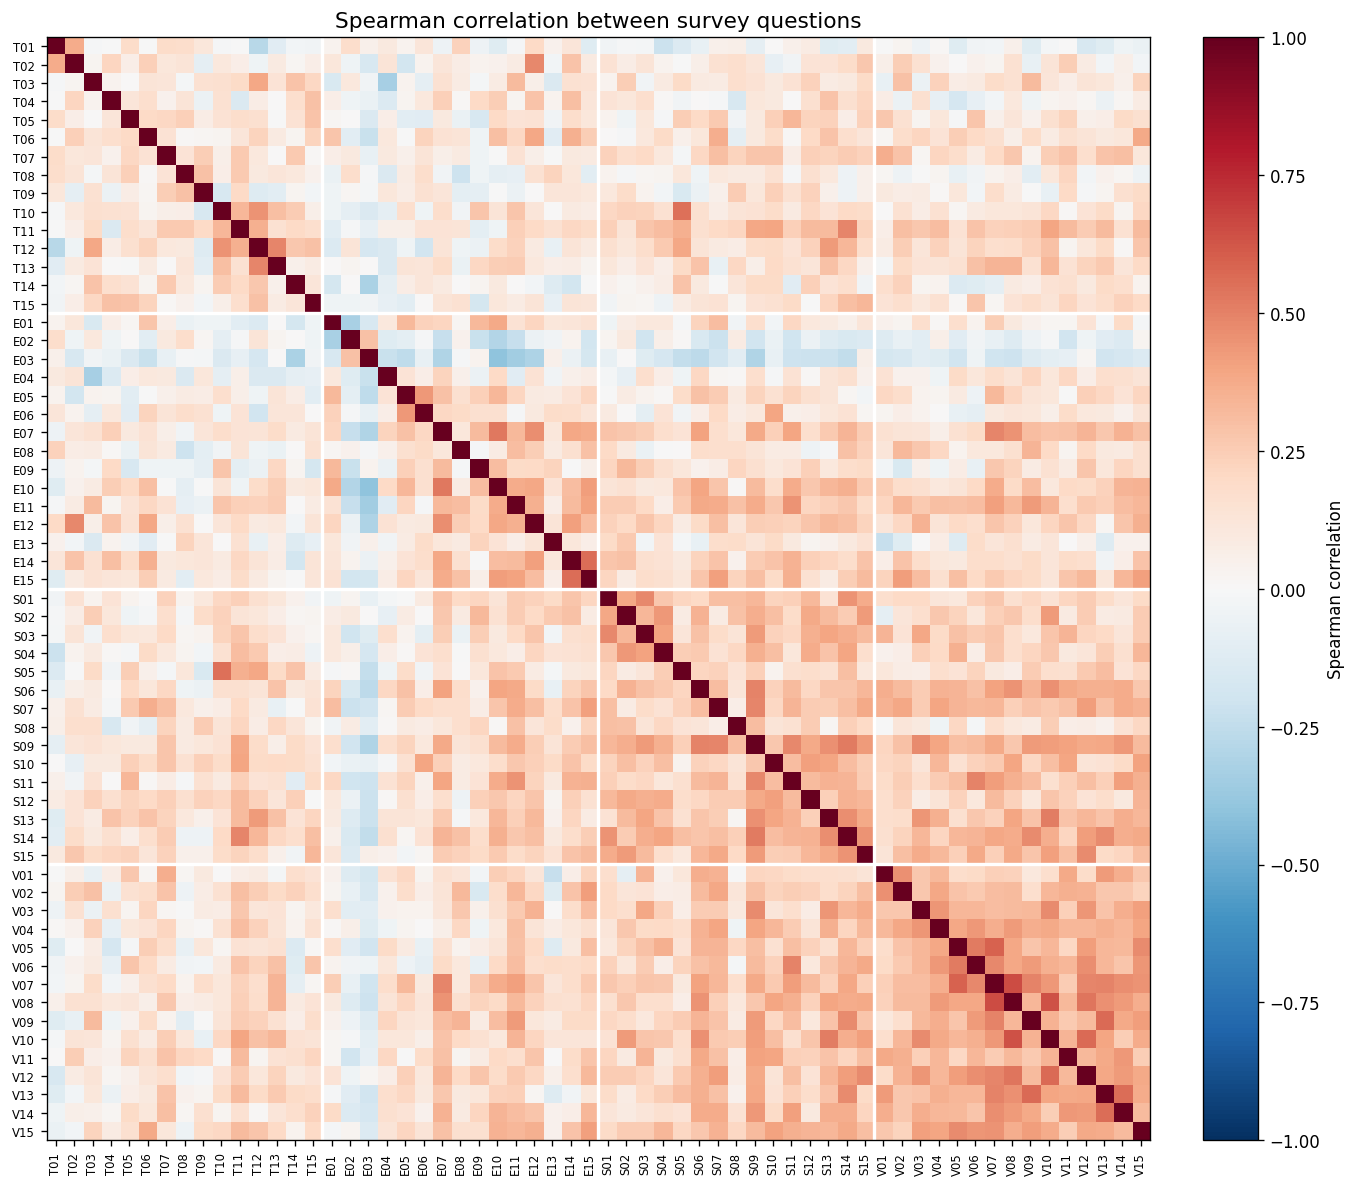

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))
heatmap = ax.imshow(
    correlation_matrix.to_numpy(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
)
ax.set_xticks(np.arange(len(question_codes)), question_codes, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(question_codes)), question_codes, fontsize=7)
for boundary in [14.5, 29.5, 44.5]:
    ax.axhline(boundary, color="white", linewidth=2)
    ax.axvline(boundary, color="white", linewidth=2)
ax.set_title("Spearman correlation between survey questions")
colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Spearman correlation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "question_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 10. Question-question network visualization

Node colour represents the questionnaire's predefined domain. Node size represents weighted strength. Blue edges are positive, red edges are negative, and edge width represents absolute correlation. Only the most strongly connected questions are labelled to keep the figure readable; the complete wording remains available in the metadata and metrics tables.

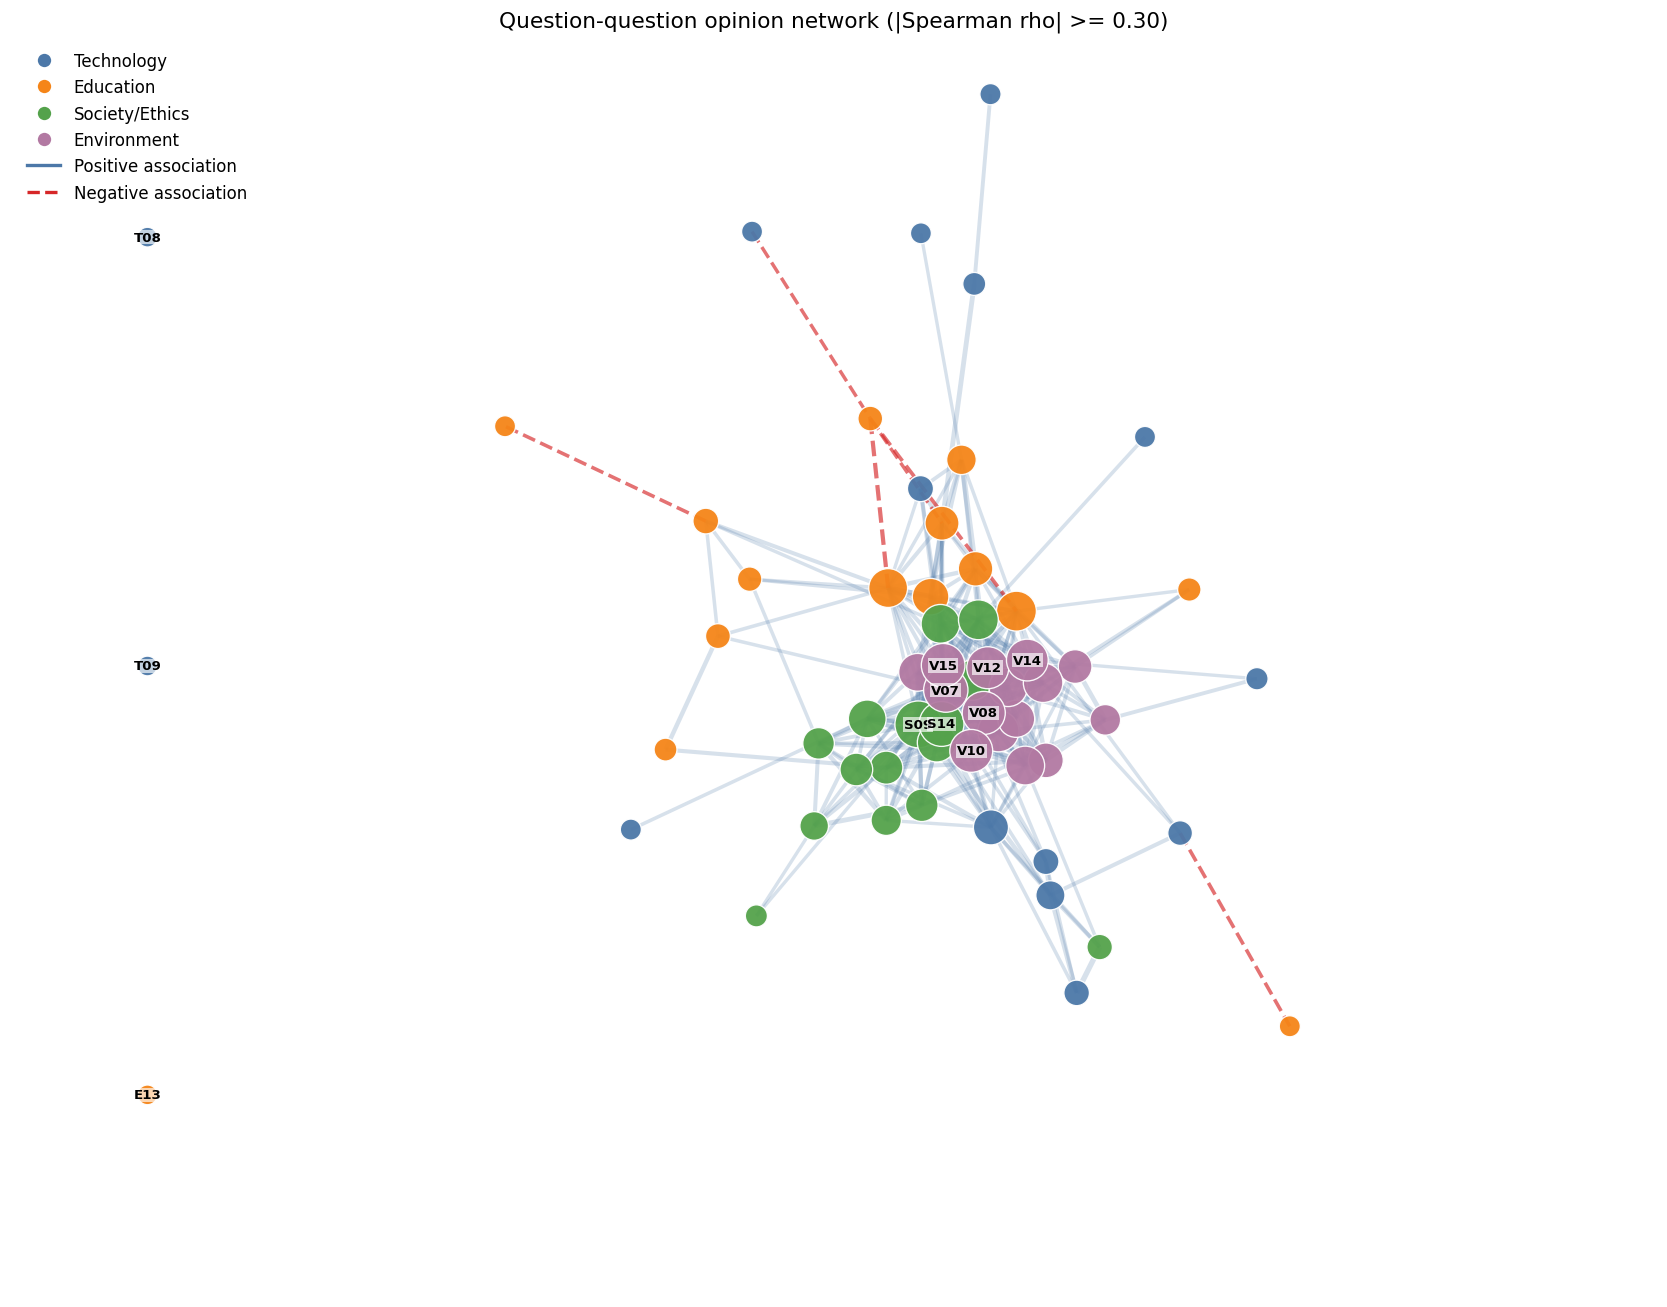

In [13]:
# Lay out the largest connected component independently so that isolates
# do not compress it into a small corner of the canvas. Remaining nodes are
# placed in a labelled side column and remain visible in the figure.
connected_components = sorted(nx.connected_components(G), key=len, reverse=True)
largest_component_nodes = connected_components[0]
largest_component_graph = G.subgraph(largest_component_nodes)
positions = nx.spring_layout(
    largest_component_graph,
    weight="weight",
    seed=RANDOM_SEED,
    k=0.65,
    iterations=500,
    scale=1.0,
)

remaining_nodes = [
    node for component in connected_components[1:] for node in sorted(component)
]
if remaining_nodes:
    remaining_y = np.linspace(0.75, -0.75, len(remaining_nodes))
    positions.update({
        node: np.array([-1.30, y_value])
        for node, y_value in zip(remaining_nodes, remaining_y)
    })

node_strengths = np.array([strength[node] for node in G.nodes], dtype=float)
if node_strengths.max() > node_strengths.min():
    node_sizes = 140 + 650 * (
        (node_strengths - node_strengths.min())
        / (node_strengths.max() - node_strengths.min())
    )
else:
    node_sizes = np.full(len(node_strengths), 300.0)

node_colors = [DOMAIN_COLORS[G.nodes[node]["domain"]] for node in G.nodes]
positive_edges = [
    (left, right) for left, right, data in G.edges(data=True)
    if data["correlation"] > 0
]
negative_edges = [
    (left, right) for left, right, data in G.edges(data=True)
    if data["correlation"] < 0
]

fig, ax = plt.subplots(figsize=(14, 11))
nx.draw_networkx_nodes(
    G, positions, node_size=node_sizes, node_color=node_colors,
    edgecolors="white", linewidths=0.8, alpha=0.95, ax=ax,
)
nx.draw_networkx_edges(
    G, positions, edgelist=positive_edges,
    width=[0.5 + 5 * G.edges[edge]["weight"] for edge in positive_edges],
    edge_color="#4C78A8", alpha=0.22, ax=ax,
)
nx.draw_networkx_edges(
    G, positions, edgelist=negative_edges,
    width=[0.5 + 5 * G.edges[edge]["weight"] for edge in negative_edges],
    edge_color="#D62728", alpha=0.65, style="dashed", ax=ax,
)

labelled_nodes = set(
    question_metrics.sort_values("strength", ascending=False).head(8).index
)
nx.draw_networkx_labels(
    G,
    positions,
    labels={node: node for node in labelled_nodes | set(remaining_nodes)},
    font_size=8,
    font_weight="bold",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 0.5},
    ax=ax,
)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=DOMAIN_COLORS[domain],
           markeredgecolor="white", markersize=9, label=domain)
    for domain in DOMAIN_ORDER
]
legend_handles.extend([
    Line2D([0], [0], color="#4C78A8", linewidth=2, label="Positive association"),
    Line2D([0], [0], color="#D62728", linewidth=2, linestyle="--", label="Negative association"),
])
ax.legend(handles=legend_handles, loc="upper left", frameon=False)
ax.set_title(
    f"Question-question opinion network (|Spearman rho| >= {PRIMARY_THRESHOLD:.2f})"
)
ax.set_xlim(-1.52, 1.15)
ax.set_ylim(-1.10, 1.10)
ax.axis("off")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "question_network.png", bbox_inches="tight")
plt.show()

## 11. Domain mixing

The domain-mixing matrix counts retained edges between Technology, Education, Society/Ethics, and Environment. Large diagonal values indicate within-domain cohesion. Large off-diagonal values identify cross-domain relationships.

Counts should be interpreted alongside the possible number of pairs: there are more possible cross-domain pairs than within-domain pairs. The second table therefore reports the proportion of possible pairs retained as edges.

Retained edge counts


,Technology,Education,Society/Ethics,Environment
Technology,7,8,14,13
Education,8,27,23,28
Society/Ethics,14,23,50,78
Environment,13,28,78,80


Share of possible domain pairs retained


,Technology,Education,Society/Ethics,Environment
Technology,0.067,0.036,0.062,0.058
Education,0.036,0.257,0.102,0.124
Society/Ethics,0.062,0.102,0.476,0.347
Environment,0.058,0.124,0.347,0.762


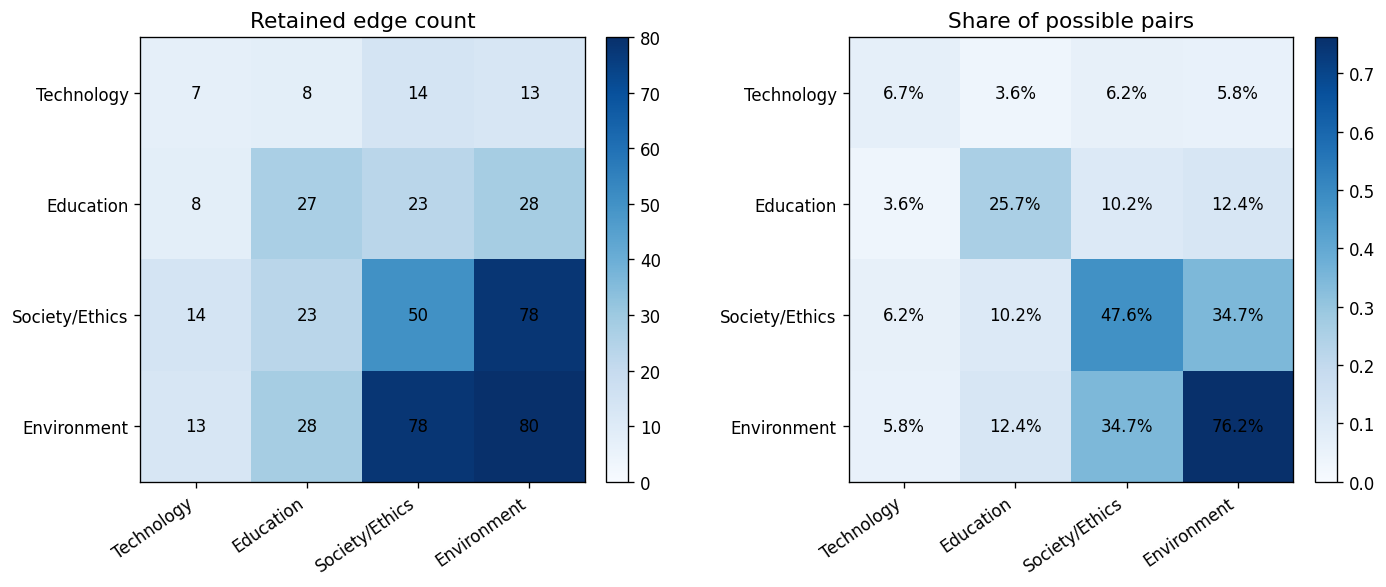

In [14]:
domain_edge_counts = pd.DataFrame(0, index=DOMAIN_ORDER, columns=DOMAIN_ORDER, dtype=int)
domain_edge_strength = pd.DataFrame(0.0, index=DOMAIN_ORDER, columns=DOMAIN_ORDER)

for left, right, data in G.edges(data=True):
    left_domain = G.nodes[left]["domain"]
    right_domain = G.nodes[right]["domain"]
    domain_edge_counts.loc[left_domain, right_domain] += 1
    domain_edge_strength.loc[left_domain, right_domain] += data["weight"]
    if left_domain != right_domain:
        domain_edge_counts.loc[right_domain, left_domain] += 1
        domain_edge_strength.loc[right_domain, left_domain] += data["weight"]

domain_sizes = question_metadata["domain"].value_counts().reindex(DOMAIN_ORDER)
possible_pairs = pd.DataFrame(0, index=DOMAIN_ORDER, columns=DOMAIN_ORDER, dtype=int)
for left_domain in DOMAIN_ORDER:
    for right_domain in DOMAIN_ORDER:
        if left_domain == right_domain:
            possible_pairs.loc[left_domain, right_domain] = (
                domain_sizes[left_domain] * (domain_sizes[left_domain] - 1) // 2
            )
        else:
            possible_pairs.loc[left_domain, right_domain] = (
                domain_sizes[left_domain] * domain_sizes[right_domain]
            )

domain_edge_share = domain_edge_counts / possible_pairs

print("Retained edge counts")
display(domain_edge_counts)
print("Share of possible domain pairs retained")
display(domain_edge_share.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in [
    (axes[0], domain_edge_counts, "Retained edge count", "d"),
    (axes[1], domain_edge_share, "Share of possible pairs", ".1%"),
]:
    image = ax.imshow(matrix.to_numpy(dtype=float), cmap="Blues", vmin=0)
    ax.set_xticks(range(len(DOMAIN_ORDER)), DOMAIN_ORDER, rotation=35, ha="right")
    ax.set_yticks(range(len(DOMAIN_ORDER)), DOMAIN_ORDER)
    ax.set_title(title)
    for row_index in range(len(DOMAIN_ORDER)):
        for column_index in range(len(DOMAIN_ORDER)):
            value = matrix.iloc[row_index, column_index]
            label = format(value, fmt)
            ax.text(column_index, row_index, label, ha="center", va="center")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "domain_mixing.png", bbox_inches="tight")
plt.show()

## 12. Agreement-tendency robustness check

Many survey statements attract agreement. A respondent who generally agrees with everything can create positive correlations across otherwise unrelated questions.

As a robustness check, this cell subtracts each respondent's mean observed response before recalculating pairwise-complete Spearman correlations. This is sometimes called respondent centering or ipsatization. It asks whether a respondent rated a question higher or lower than their personal average.

The uncentered network remains the primary result because centering changes the interpretation and can create artificial dependence among items. The comparison identifies relationships that survive both definitions.

In [15]:
respondent_centered = numeric_eligible.sub(numeric_eligible.mean(axis=1), axis=0)
centered_correlation = respondent_centered.corr(
    method="spearman",
    min_periods=MIN_PAIRWISE_RESPONSES,
)

def edge_set_from_matrix(matrix, threshold):
    edges = set()
    for left_index, left_code in enumerate(question_codes):
        for right_index in range(left_index + 1, len(question_codes)):
            right_code = question_codes[right_index]
            value = matrix.loc[left_code, right_code]
            paired_n = int(pairwise_counts.loc[left_code, right_code])
            if (
                np.isfinite(value)
                and paired_n >= MIN_PAIRWISE_RESPONSES
                and abs(value) >= threshold
            ):
                edges.add((left_code, right_code))
    return edges

raw_edge_set = edge_set_from_matrix(correlation_matrix, PRIMARY_THRESHOLD)
centered_edge_set = edge_set_from_matrix(centered_correlation, PRIMARY_THRESHOLD)
shared_edge_set = raw_edge_set & centered_edge_set
union_edge_set = raw_edge_set | centered_edge_set

robustness_summary = pd.Series({
    "Raw-network edges": len(raw_edge_set),
    "Respondent-centered edges": len(centered_edge_set),
    "Edges present in both": len(shared_edge_set),
    "Jaccard edge overlap": (
        len(shared_edge_set) / len(union_edge_set) if union_edge_set else np.nan
    ),
}, name="Value")
display(robustness_summary.to_frame())

shared_edge_keys = {tuple(sorted(edge)) for edge in shared_edge_set}
robust_edges = edge_table[
    edge_table.apply(
        lambda row: tuple(sorted((row["question_1"], row["question_2"])))
        in shared_edge_keys,
        axis=1,
    )
].copy()
print("Strongest raw-network edges that also survive respondent centering")
display(robust_edges.head(20))

,Value
Raw-network edges,328.000000
Respondent-centered edges,41.000000
Edges present in both,25.000000
Jaccard edge overlap,0.072674


Strongest raw-network edges that also survive respondent centering


,question_1,question_2,domain_1,domain_2,correlation,absolute_correlation,sign,paired_n
296,V07,V08,Environment,Environment,0.651526,0.651526,positive,85
304,V08,V10,Environment,Environment,0.633418,0.633418,positive,85
281,V05,V07,Environment,Environment,0.590888,0.590888,positive,85
316,V10,V12,Environment,Environment,0.565415,0.565415,positive,84
312,V09,V13,Environment,Environment,0.562691,0.562691,positive,85
325,V13,V14,Environment,Environment,0.559433,0.559433,positive,85
110,E14,E15,Education,Education,0.555197,0.555197,positive,87
18,T10,S05,Technology,Society/Ethics,0.547460,0.547460,positive,87
55,E07,E10,Education,Education,0.525912,0.525912,positive,87
280,V05,V06,Environment,Environment,0.515868,0.515868,positive,84


## 13. Export reproducible results

The final cell exports tidy CSV files and the preceding cells save the figures. The exports contain question-level and edge-level results only; respondent IDs and individual response vectors are not written to the output directory.

In [16]:
question_summary.to_csv(OUTPUT_DIR / "question_summary.csv", index_label="question_code")
question_metrics.to_csv(OUTPUT_DIR / "question_network_metrics.csv", index_label="question_code")
correlation_matrix.to_csv(OUTPUT_DIR / "spearman_correlation_matrix.csv", index_label="question_code")
pairwise_counts.to_csv(OUTPUT_DIR / "pairwise_sample_sizes.csv", index_label="question_code")
edge_table.to_csv(OUTPUT_DIR / "question_network_edges.csv", index=False)
threshold_sensitivity.to_csv(OUTPUT_DIR / "threshold_sensitivity.csv")
domain_edge_counts.to_csv(OUTPUT_DIR / "domain_edge_counts.csv")
domain_edge_share.to_csv(OUTPUT_DIR / "domain_edge_shares.csv")

exported_files = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
print("Exported files:")
for file_name in exported_files:
    print(f"- {file_name}")

Exported files:
- domain_edge_counts.csv
- domain_edge_shares.csv
- domain_mixing.png
- likert_distributions.png
- pairwise_sample_sizes.csv
- question_correlation_heatmap.png
- question_network.png
- question_network_edges.csv
- question_network_metrics.csv
- question_summary.csv
- spearman_correlation_matrix.csv
- threshold_sensitivity.csv


## Limitations

- The analysis is correlational and cannot establish causation.
- Likert responses are ordinal; Spearman correlation respects ordering but still reduces complex opinions to ranks.
- Missing responses are handled pairwise, so question-pair correlations can use slightly different subsets of respondents. Every retained pair must still meet the minimum shared sample size.
- The sample represents the surveyed class and should not be generalized to a wider population.
- Communities are algorithmic summaries, not proof that discrete ideological groups exist.